### Import libs

In [48]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd
import numpy as np

### Import dataset

In [39]:
df = pd.read_csv('../data/processed_dataset.csv')

### Define Bayesian model with PyMC 

In [40]:
# Define X and y

channels = ["tv_sat", "youtube_sat", "facebook_sat", "search_sat"]
y = df["sales"].values
X = df[channels].values

#Model

with pm.Model() as mmm_model:
    
    # Intercept
    beta_0 = pm.Normal("beta_0", mu=0, sigma=10000)
    
    # Coeficientes por canal (positivos)
    betas = pm.HalfNormal("betas", sigma=10000, shape=len(channels))
    
    # Error
    sigma = pm.HalfNormal("sigma", sigma=5000)
    
    # Modelo lineal
    mu = beta_0 + pm.math.dot(X, betas)
    
    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)
    
    # Inferencia
    trace = pm.sample(2000, tune=1000, target_accept=0.95, random_seed=42)
    

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0, betas, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 10605 seconds.


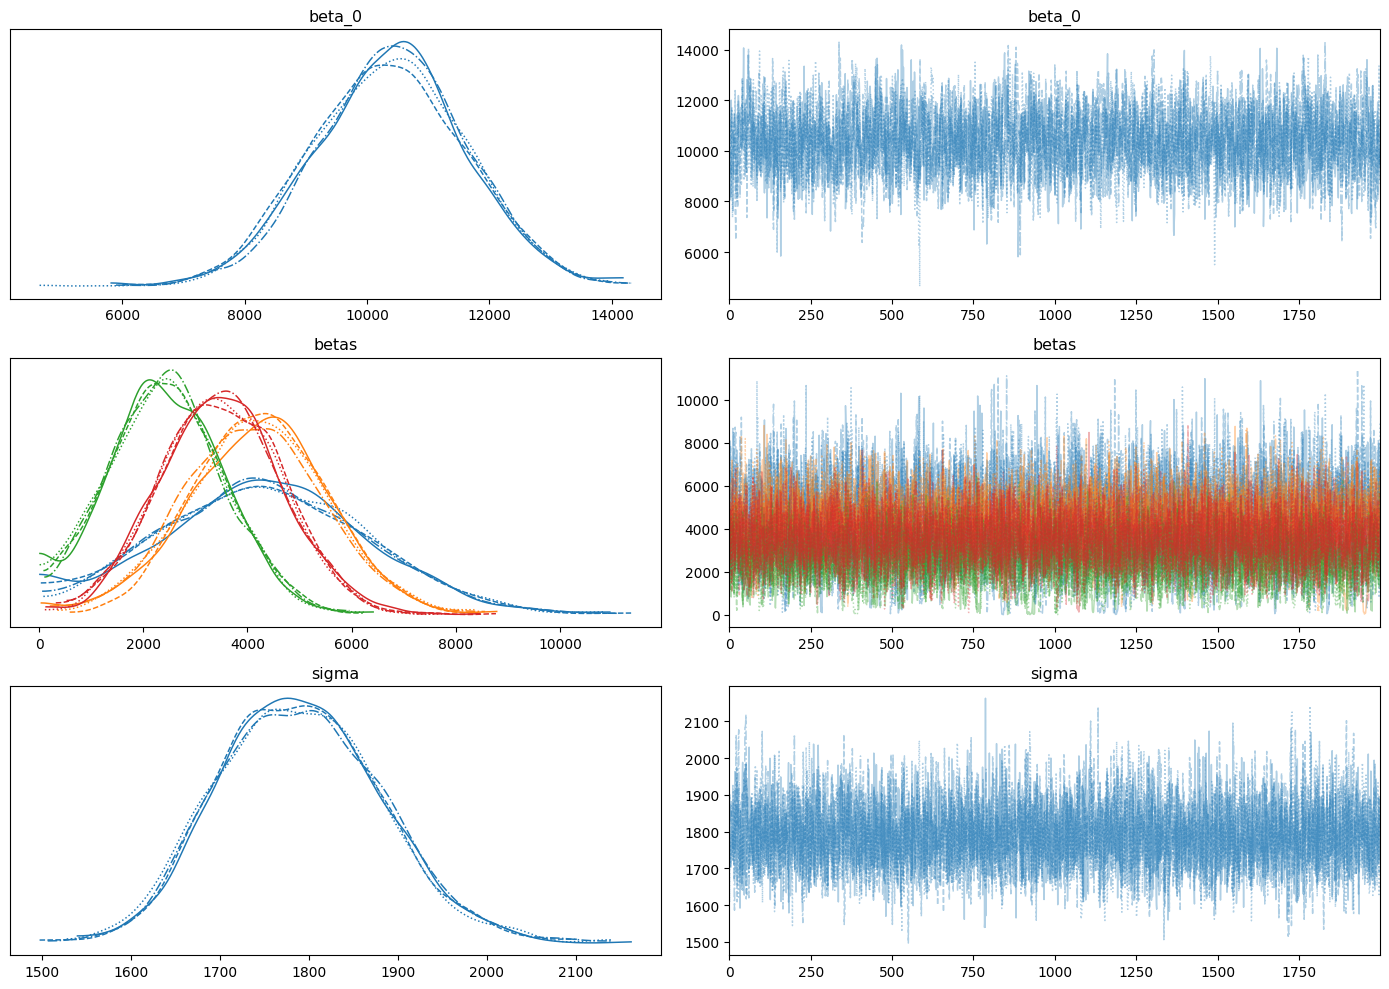

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_0,10380.83,1234.91,8098.77,12698.06,24.77,14.65,2480.88,3730.03,1.0
betas[0],4332.04,1959.40,696.46,7978.01,34.70,26.60,2920.61,1415.11,1.0
betas[1],4189.84,1319.80,1655.93,6634.96,23.84,20.26,3055.30,1859.23,1.0
betas[2],2443.00,1086.61,313.00,4348.73,18.98,14.68,2818.72,1502.42,1.0
betas[3],3491.31,1155.18,1343.00,5674.79,17.21,14.26,4373.79,3106.56,1.0
sigma,1789.99,90.66,1619.63,1955.09,1.20,1.10,5763.91,5062.28,1.0


In [83]:
fig = az.plot_trace(trace, figsize=(14, 10))
plt.tight_layout()
plt.show()

trace_summary = az.summary(trace, round_to=2)
trace_summary

In [ ]:
betas_mean = np.array(trace_summary['mean'][:-1]) 
df_betas = pd.DataFrame(betas_mean, index=['beta_0','tv','youtube','facebook','search'], columns=['beta'])
df_betas.to_csv('../data/betas_mean.csv', index=True)

,beta
beta_0,10380.83
tv,4332.04
youtube,4189.84
facebook,2443.00
search,3491.31


### Channel contribution

tv_sat: 2150.71 estimated contribution to sales
youtube_sat: 2060.34 estimated contribution to sales
facebook_sat: 1193.26 estimated contribution to sales
search_sat: 1707.46 estimated contribution to sales


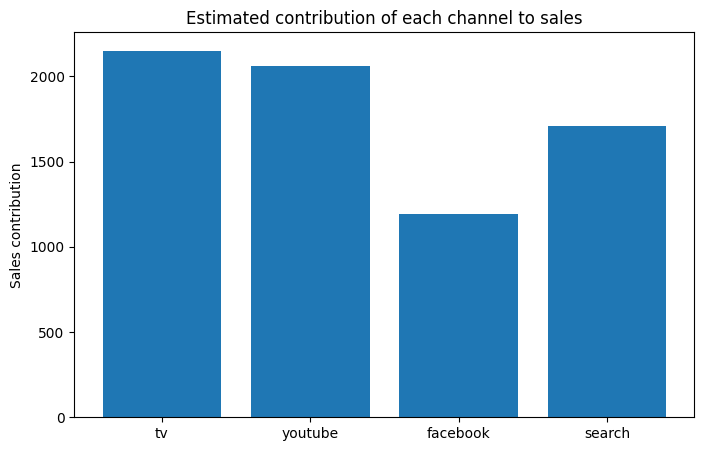

In [42]:
# Estimating the contribution of each channel to sales 

posterior_means = trace.posterior["betas"].mean(dim=["chain","draw"]).values
contributions = posterior_means * df[channels].mean().values

for ch, contrib in zip(channels, contributions):
    print(f"{ch}: {contrib:.2f} estimated contribution to sales")
    
#Plot of contributions

plt.figure(figsize=(8,5))
plt.bar([ch.replace("_sat","") for ch in channels], contributions)
plt.title("Estimated contribution of each channel to sales")
plt.ylabel("Sales contribution")
plt.show()


### Sales breakdown over time

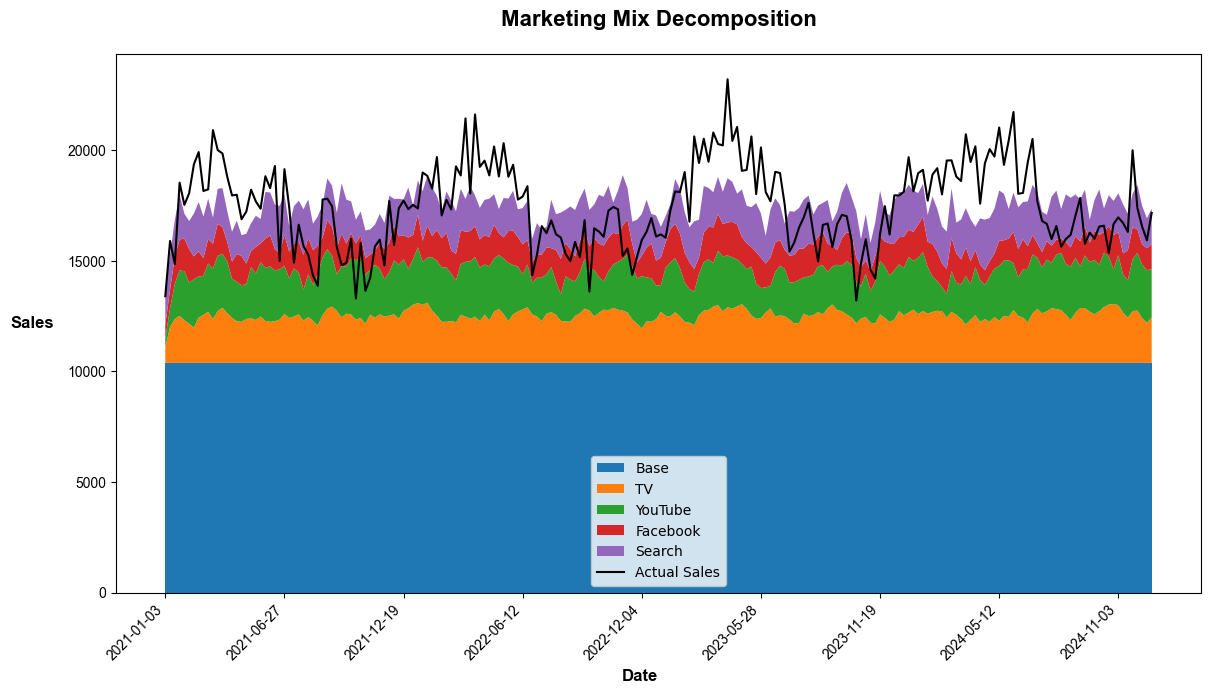

In [43]:
#Extract mean coefficients

beta_0_mean = trace.posterior["beta_0"].mean().values
betas_mean = trace.posterior["betas"].mean(dim=["chain","draw"]).values

#calculate weekly contribution

contribution_df = pd.DataFrame()

contribution_df['date'] = df['date']
contribution_df['base'] = beta_0_mean
channels = ["tv_sat", "youtube_sat", "facebook_sat", "search_sat"]

for i, ch in enumerate (channels):
    contribution_df[ch] = df[ch] * betas_mean[i]
contribution_df['sales'] = df['sales']

#Plot

plt.figure(figsize=(14,7))

plt.stackplot(
    contribution_df["date"],
    contribution_df["base"],
    contribution_df["tv_sat"],
    contribution_df["youtube_sat"],
    contribution_df["facebook_sat"],
    contribution_df["search_sat"],
    labels=["Base","TV","YouTube","Facebook","Search"]
)

plt.xlabel ('Date', fontsize=12, color='black', fontweight='bold', labelpad=10, rotation=0, ha='right', va='center', fontfamily='Arial')
plt.ylabel('Sales',  fontsize=12, color='black', fontweight='bold', labelpad=10, rotation=0, ha='right', va='center', fontfamily='Arial')
plt.plot(contribution_df["date"], contribution_df["sales"], color="black", label="Actual Sales")
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=10))

plt.xticks(rotation=45, ha='right', fontsize=10, color='black', fontfamily='Arial')
plt.yticks(fontsize=10, color='black', fontfamily='Arial')
plt.legend()

plt.title("Marketing Mix Decomposition",  fontsize=16, color='black', fontweight='bold', pad=20, fontfamily='Arial')

plt.show()

In [44]:
total_base = contribution_df["base"].sum()

total_tv = contribution_df["tv_sat"].sum()
total_youtube = contribution_df["youtube_sat"].sum()
total_facebook = contribution_df["facebook_sat"].sum()
total_search = contribution_df["search_sat"].sum()

total_media = total_tv + total_youtube + total_facebook + total_search

total_sales = contribution_df["sales"].sum()

print("Base sales:", total_base)
print("Media sales:", total_media)
print("Total sales:", total_sales)

print("\nPercentages:")

print("Base %:", total_base / total_sales * 100)
print("Media %:", total_media / total_sales * 100)

Base sales: 2159213.155972742
Media sales: 1479249.0343982633
Total sales: 3639127.32357655

Percentages:
Base %: 59.33326767612675
Media %: 40.648455051703195


The Bayesian Marketing Mix Model estimated that paid media contributed 37% of total sales, while 63% were driven by baseline factors such as brand equity and organic demand.

### ROAS per channel

In [45]:
roas = {}

media_channels = ["tv", "youtube", "facebook", "search"]

for ch in media_channels:

    contribution = contribution_df[f"{ch}_sat"].sum()

    spend = df[ch].sum()

    roas[ch] = contribution / spend

roas

{'tv': np.float64(0.07359225024446073),
 'youtube': np.float64(1.1572179346970302),
 'facebook': np.float64(1.0313570166734691),
 'search': np.float64(0.28635198388732835)}

YouTube showed the highest efficiency with a ROAS above 1, while TV and Search showed significantly lower returns, suggesting potential budget reallocation opportunities.

### Response curves

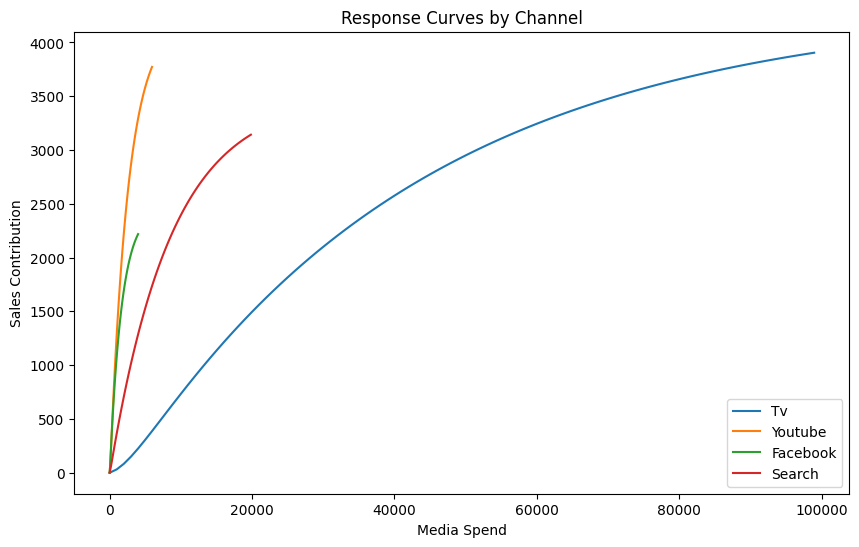

In [63]:
def adstock_transform(x, theta):

    result = np.zeros_like(x)

    for t in range(len(x)):

        result[t] = x[t] + (result[t-1] * theta if t > 0 else 0)

    return result


# Import theta and lambda from csv files

lam_values = pd.read_csv('../data/lam_values.csv')
theta_values = pd.read_csv('../data/theta_values.csv')

channels = ["tv", "youtube", "facebook", "search"]

# Diccionarios para los parámetros
betas = dict(zip(channels, betas_mean))   # betas_mean debe tener el orden [TV, YT, FB, Search]
thetas = {ch: theta_values[ch].iloc[0] for ch in channels}
lambdas = {ch: lam_values[f"{ch}_adstock"].iloc[0] for ch in channels}
max_spend = {ch: df[ch].max()*2 for ch in channels}

# Plot all response curves
plt.figure(figsize=(10,6))

for ch in channels:
    spend_range = np.linspace(0, max_spend[ch], 100)
    adstocked = adstock_transform(spend_range, thetas[ch])
    saturated = 1 - np.exp(-lambdas[ch] * adstocked)
    response = betas[ch] * saturated
    plt.plot(spend_range, response, label=ch.capitalize())

plt.xlabel("Media Spend")
plt.ylabel("Sales Contribution")
plt.title("Response Curves by Channel")
plt.legend()
plt.show()


TV requires high spend to reach its maximum contribution, while digital channels saturate quickly, demonstrating high efficiency with a low budget.